In [1]:
# Customer Intelligence System

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation:")
df.info()

print("\nStatistics:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (167, 10)

Columns:
Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Statistics:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000



Missing Values:


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


Duplicate Rows: 0


In [5]:
df.drop_duplicates(inplace=True)
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

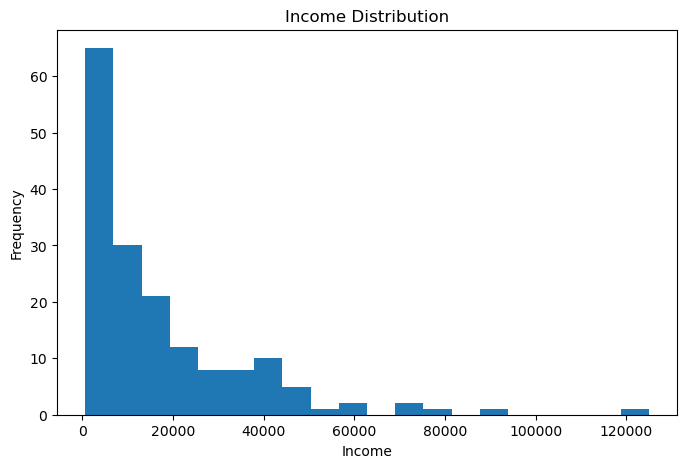

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df["income"], bins=20)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

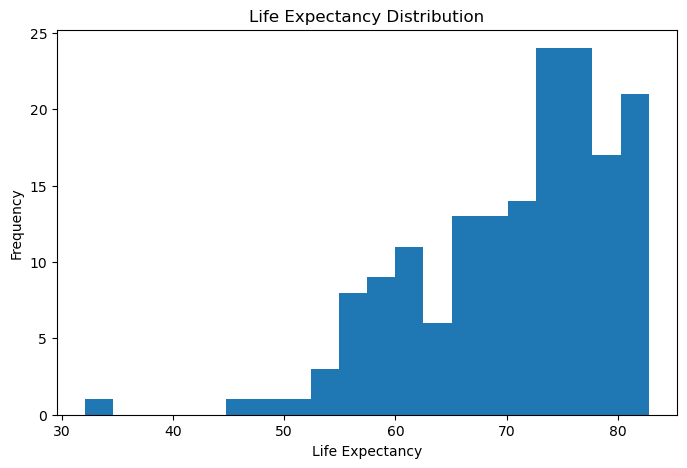

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["life_expec"], bins=20)
plt.title("Life Expectancy Distribution")
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.show()

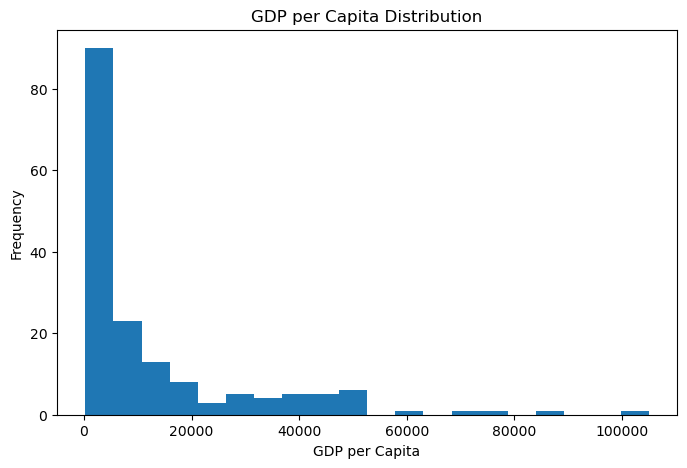

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["gdpp"], bins=20)
plt.title("GDP per Capita Distribution")
plt.xlabel("GDP per Capita")
plt.ylabel("Frequency")
plt.show()

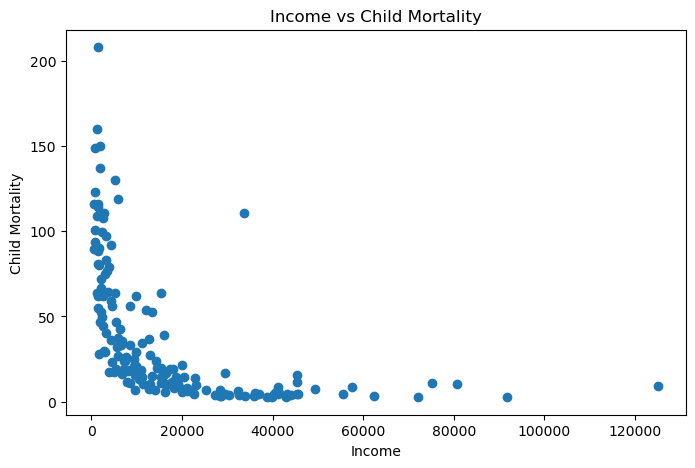

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["income"],
    df["child_mort"]
)
plt.xlabel("Income")
plt.ylabel("Child Mortality")
plt.title("Income vs Child Mortality")
plt.show()

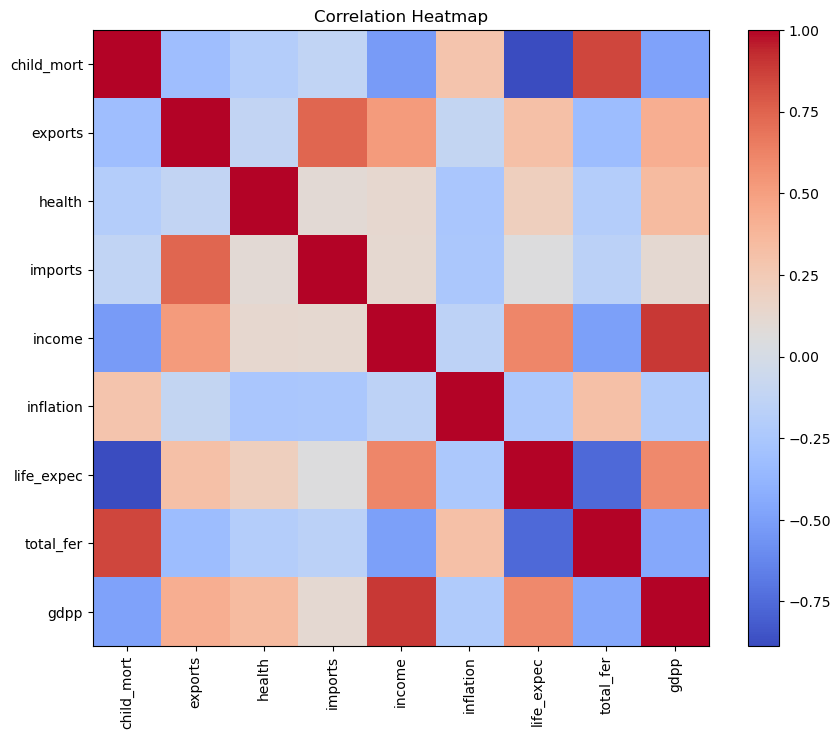

In [10]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns
)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

In [11]:
X = df.drop(columns=["country"])

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)
clusters = kmeans.fit_predict(X_scaled)

In [14]:
df["Cluster"] = clusters
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [15]:
print(df["Cluster"].value_counts())

Cluster
0    86
2    45
1    36
Name: count, dtype: int64


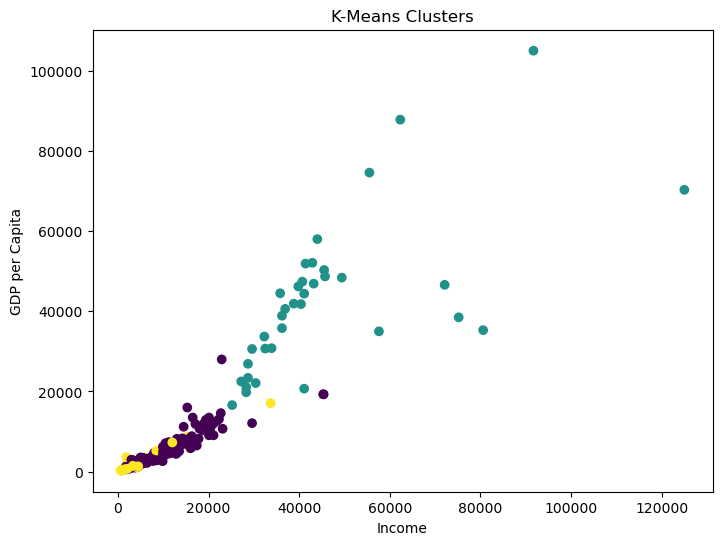

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["income"],
    df["gdpp"],
    c=df["Cluster"],
    cmap="viridis"
)
plt.xlabel("Income")
plt.ylabel("GDP per Capita")
plt.title("K-Means Clusters")
plt.show()

In [17]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)
db_clusters = dbscan.fit_predict(X_scaled)

In [18]:
df["DBSCAN_Cluster"] = db_clusters

In [19]:
print(df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


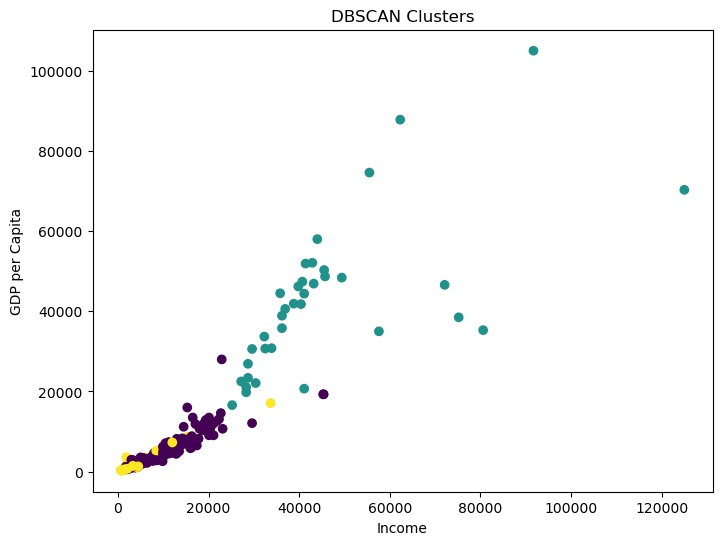

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["income"],
    df["gdpp"],
    c=df["Cluster"],
    cmap="viridis"
)
plt.xlabel("Income")
plt.ylabel("GDP per Capita")
plt.title("DBSCAN Clusters")
plt.show()

In [21]:
X = df.drop(columns=["country", "Cluster", "DBSCAN_Cluster"])
y = df["Cluster"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
rf = RandomForestClassifier(
    random_state=42
)

In [24]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [25]:
rf_predictions = rf.predict(X_test)

In [26]:
print("Accuracy:", accuracy_score(y_test, rf_predictions))

Accuracy: 1.0


In [27]:
print(confusion_matrix(y_test, rf_predictions))

[[20  0  0]
 [ 0  8  0]
 [ 0  0  6]]


In [28]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [29]:
from xgboost import XGBClassifier

In [30]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

In [31]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [32]:
xgb_predictions = xgb.predict(X_test)

In [33]:
print("Accuracy:", accuracy_score(y_test, xgb_predictions))

Accuracy: 1.0


In [34]:
print(confusion_matrix(y_test, xgb_predictions))

[[20  0  0]
 [ 0  8  0]
 [ 0  0  6]]


In [35]:
print(classification_report(y_test, xgb_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [36]:
print("Project Summary")
print("-" * 40)

print("Total Countries:", len(df))
print("K-Means Clusters:", df["Cluster"].nunique())
print("DBSCAN Clusters:", df["DBSCAN_Cluster"].nunique())

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, rf_predictions))

print("\nXGBoost Accuracy:")
print(accuracy_score(y_test, xgb_predictions))

Project Summary
----------------------------------------
Total Countries: 167
K-Means Clusters: 3
DBSCAN Clusters: 2

Random Forest Accuracy:
1.0

XGBoost Accuracy:
1.0
